# Feature Engineering Analysis

This notebook:
- Builds the feature matrix from training windows
- Visualises feature distributions (normal vs incident)
- Checks for NaN / Inf values
- Inspects feature scaling before and after StandardScaler
- Shows a UMAP / PCA projection to see if positive/negative windows are separable

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path

from src.data.loader import load_smd, split_machines
from src.data.windows import make_windows_for_machines
from src.features.engineer import FeaturePipeline, extract_features, get_feature_names

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

with open('../configs/config.yaml') as f:
    cfg = yaml.safe_load(f)

W, H, step = cfg['window']['W'], cfg['window']['H'], cfg['window']['step']
SUB_WINDOWS = cfg['features']['sub_windows']
print(f'W={W}  H={H}  sub_windows={SUB_WINDOWS}')

W=60  H=10  sub_windows=[15, 30, 60]


## 1. Build Feature Matrix

In [2]:
machines = load_smd(path_to_dataset) # change path
train_ms, val_ms, test_ms = split_machines(
    machines,
    val_frac=cfg['split']['val_frac'],
    test_frac=cfg['split']['test_frac'],
    seed=cfg['split']['seed'],
)

X_tr_raw, y_tr, _ = make_windows_for_machines(train_ms, W, H, step)
X_va_raw, y_va, _ = make_windows_for_machines(val_ms,   W, H, step)

print(f'Train windows: {X_tr_raw.shape}  pos rate: {y_tr.mean():.2%}')
print(f'Val   windows: {X_va_raw.shape}  pos rate: {y_va.mean():.2%}')

def extract_features_batched(X, sub_windows, batch_size=50_000):
    parts = []
    for start in range(0, len(X), batch_size):
        parts.append(extract_features(X[start : start + batch_size], sub_windows))
        print(f"  {min(start + batch_size, len(X)):,} / {len(X):,}", end="\r")
    print()
    return np.concatenate(parts, axis=0)

X_tr_feats_raw = extract_features_batched(X_tr_raw, SUB_WINDOWS)

feat_names = get_feature_names(W, X_tr_raw.shape[2], SUB_WINDOWS)

print(f'\nFeature matrix shape: {X_tr_feats_raw.shape}')
print(f'Feature names (first 5): {feat_names[:5]}')
print(f'Total feature groups: rolling_stats + diff_stats + trend + zcr + peak')

Train windows: (996194, 60, 38)  pos rate: 2.22%
Val   windows: (219379, 60, 38)  pos rate: 2.71%
  996,194 / 996,194

Feature matrix shape: (996194, 798)
Feature names (first 5): ['roll15_mean_f0', 'roll15_mean_f1', 'roll15_mean_f2', 'roll15_mean_f3', 'roll15_mean_f4']
Total feature groups: rolling_stats + diff_stats + trend + zcr + peak


## 2. Data Integrity Checks

In [3]:
nan_count = np.isnan(X_tr_feats_raw).sum()
inf_count = np.isinf(X_tr_feats_raw).sum()
print(f'NaN values  : {nan_count}')
print(f'Inf values  : {inf_count}')

# check value range per feature group
F_raw = X_tr_raw.shape[2]
group_sizes = {
    'rolling_stats': 5 * len(SUB_WINDOWS) * F_raw,
    'diff_stats':    3 * F_raw,
    'trend_slope':   F_raw,
    'zcr':           F_raw,
    'peak_frac':     F_raw,
}
start = 0
print('\nFeature group ranges:')
for name, size in group_sizes.items():
    block = X_tr_feats_raw[:, start:start+size]
    print(f'  {name:15s}  min={block.min():.3f}  max={block.max():.3f}  mean={block.mean():.3f}')
    start += size

if nan_count == 0 and inf_count == 0:
    print('\n No NaN or Inf values - feature extraction is clean.')

NaN values  : 0
Inf values  : 0

Feature group ranges:
  rolling_stats    min=0.000  max=1.000  mean=0.112
  diff_stats       min=-0.017  max=0.652  mean=0.010
  trend_slope      min=-0.025  max=0.025  mean=-0.000
  zcr              min=0.000  max=1.000  mean=0.342
  peak_frac        min=0.000  max=0.100  mean=0.062

 No NaN or Inf values - feature extraction is clean.


## 3. Feature Distributions: Normal vs Incident Windows

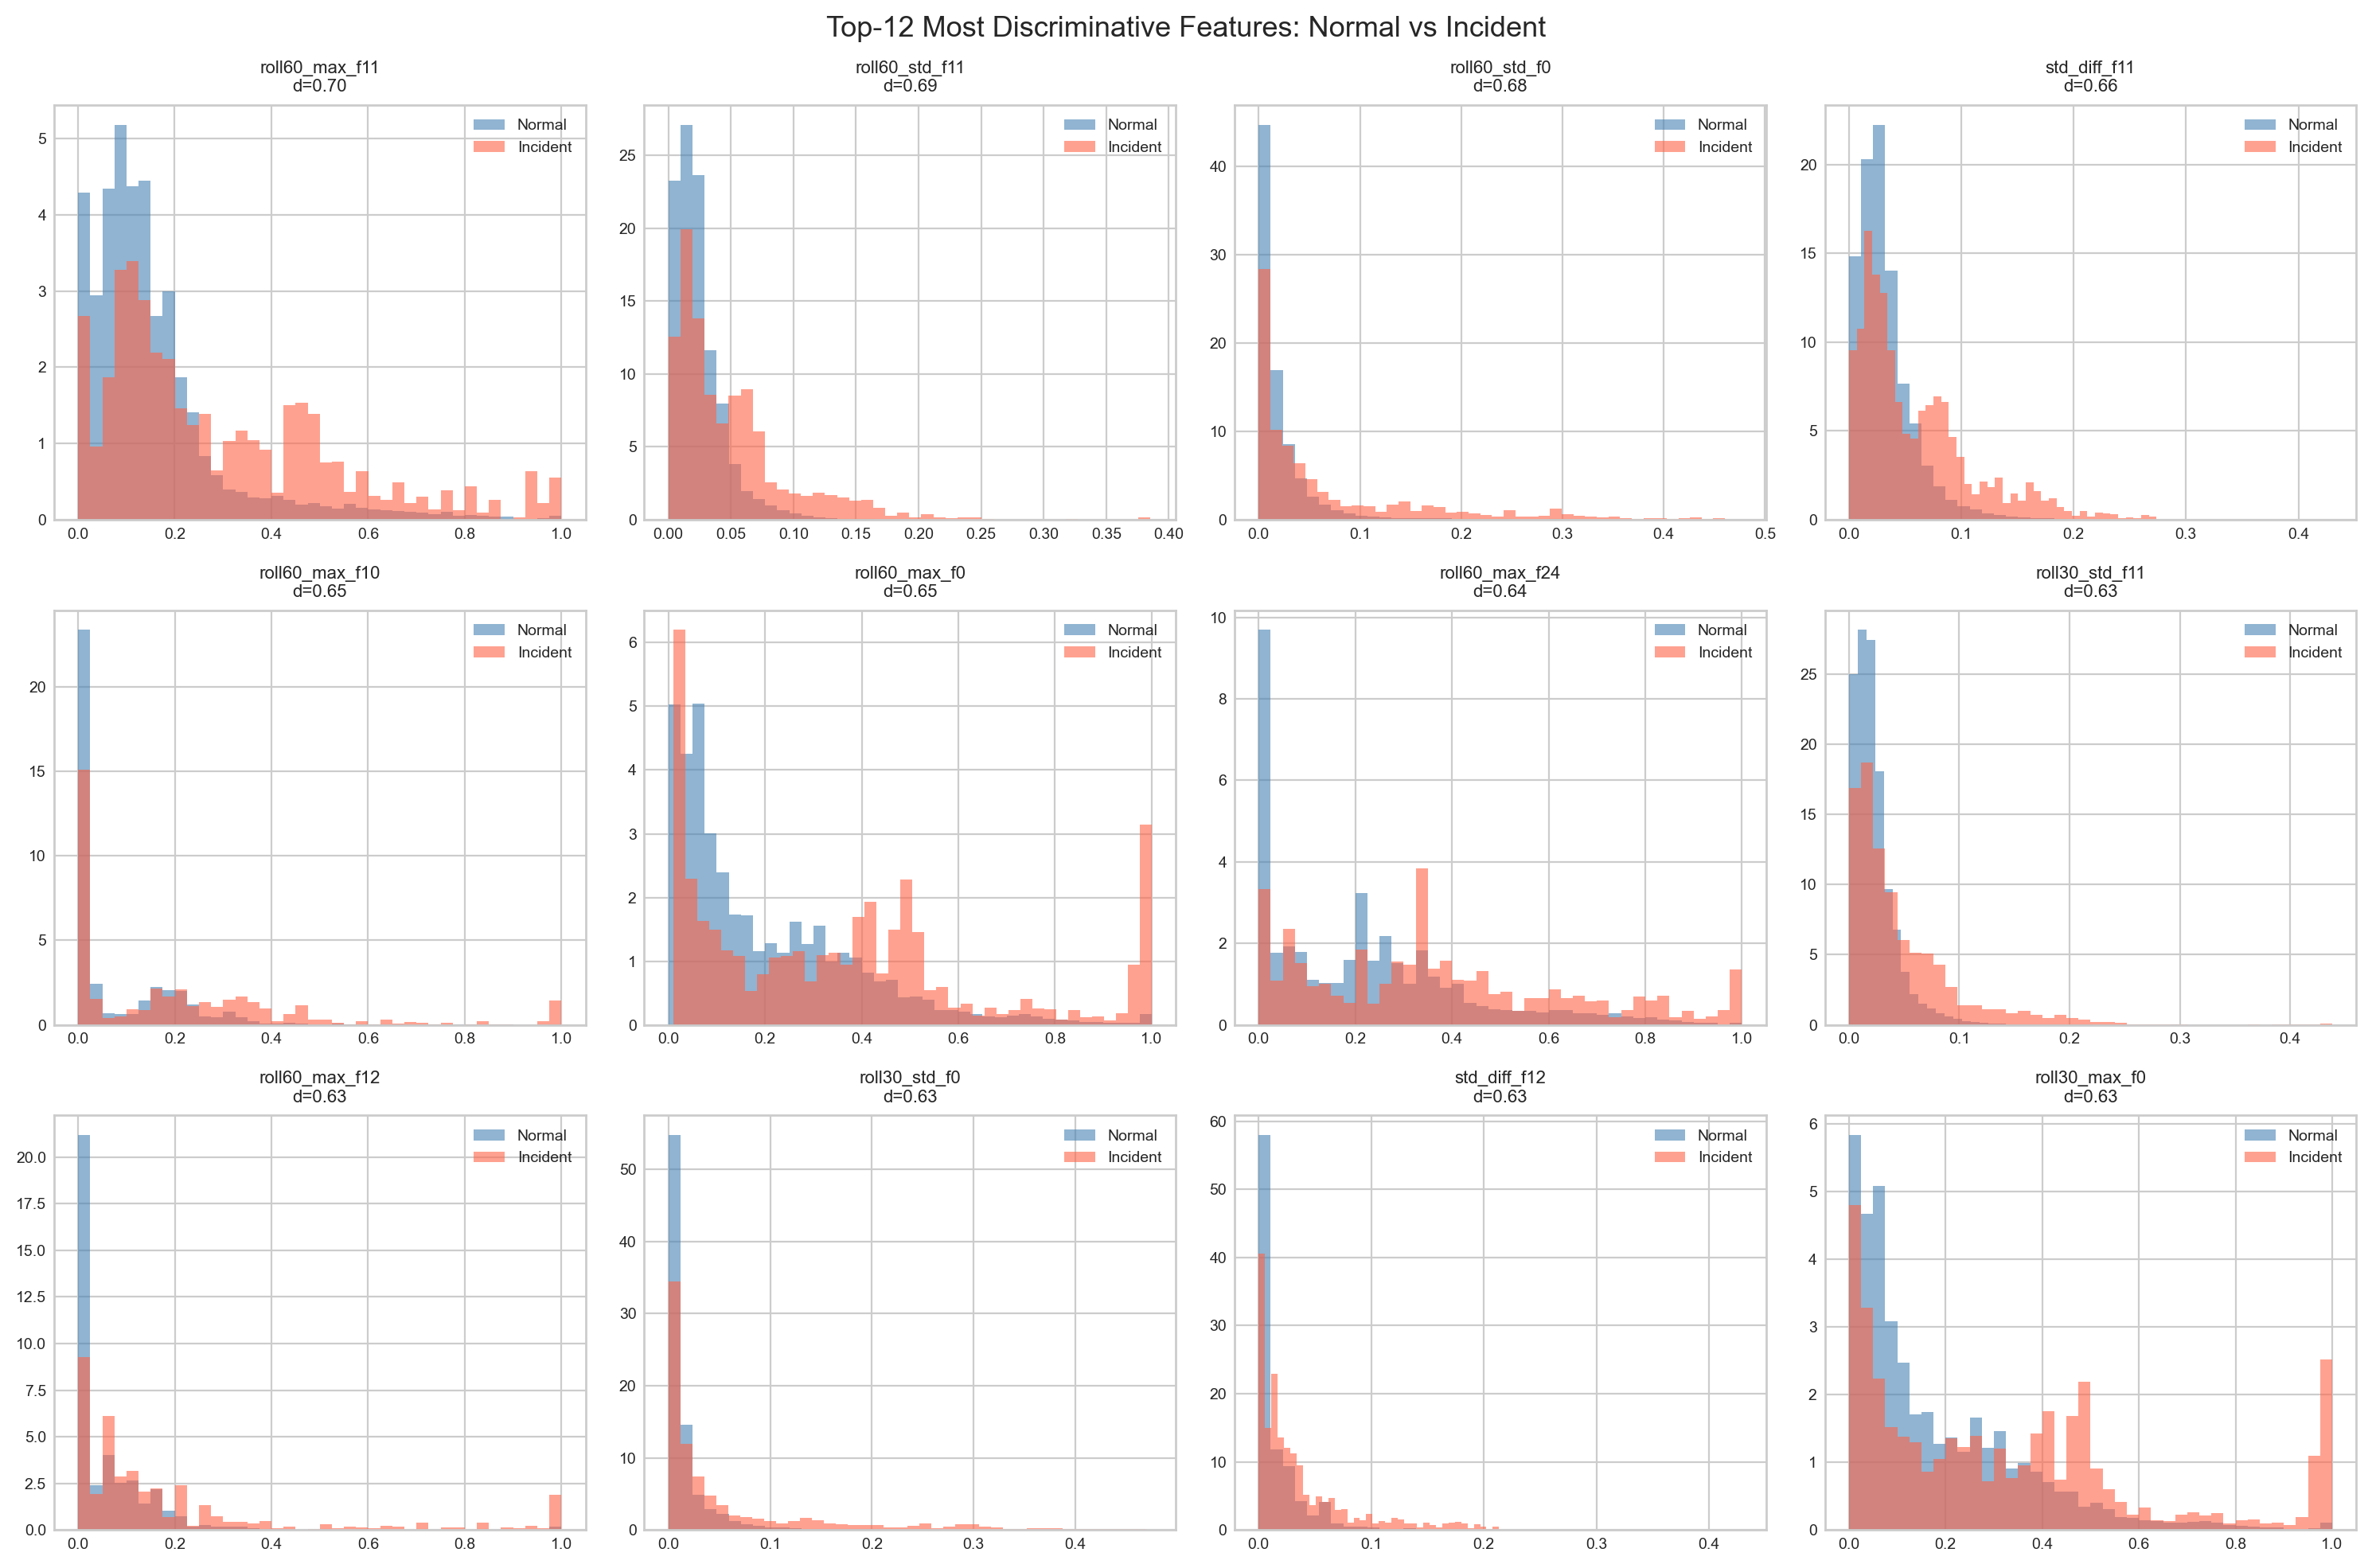

In [4]:
# compare distribution of the most discriminative features between normal (y=0) and incident (y=1) windows

pos_mask = y_tr == 1
neg_mask = y_tr == 0

means_pos = X_tr_feats_raw[pos_mask].mean(0)
means_neg = X_tr_feats_raw[neg_mask].mean(0)
std_pool  = np.sqrt((X_tr_feats_raw[pos_mask].std(0)**2 +
                     X_tr_feats_raw[neg_mask].std(0)**2) / 2 + 1e-8)
cohen_d   = np.abs(means_pos - means_neg) / std_pool

top_feat_idx = np.argsort(cohen_d)[-12:][::-1]

fig, axes = plt.subplots(3, 4, figsize=(15, 10))
for ax, idx in zip(axes.flat, top_feat_idx):
    vals_pos = X_tr_feats_raw[pos_mask, idx]
    vals_neg = X_tr_feats_raw[neg_mask, idx]
    ax.hist(vals_neg, bins=40, alpha=0.6, color='steelblue', label='Normal',   density=True)
    ax.hist(vals_pos, bins=40, alpha=0.6, color='tomato',    label='Incident', density=True)
    fname = feat_names[idx] if idx < len(feat_names) else f'feat_{idx}'
    ax.set_title(f'{fname[:25]}\nd={cohen_d[idx]:.2f}', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

plt.suptitle('Top-12 Most Discriminative Features: Normal vs Incident', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Effect of StandardScaler

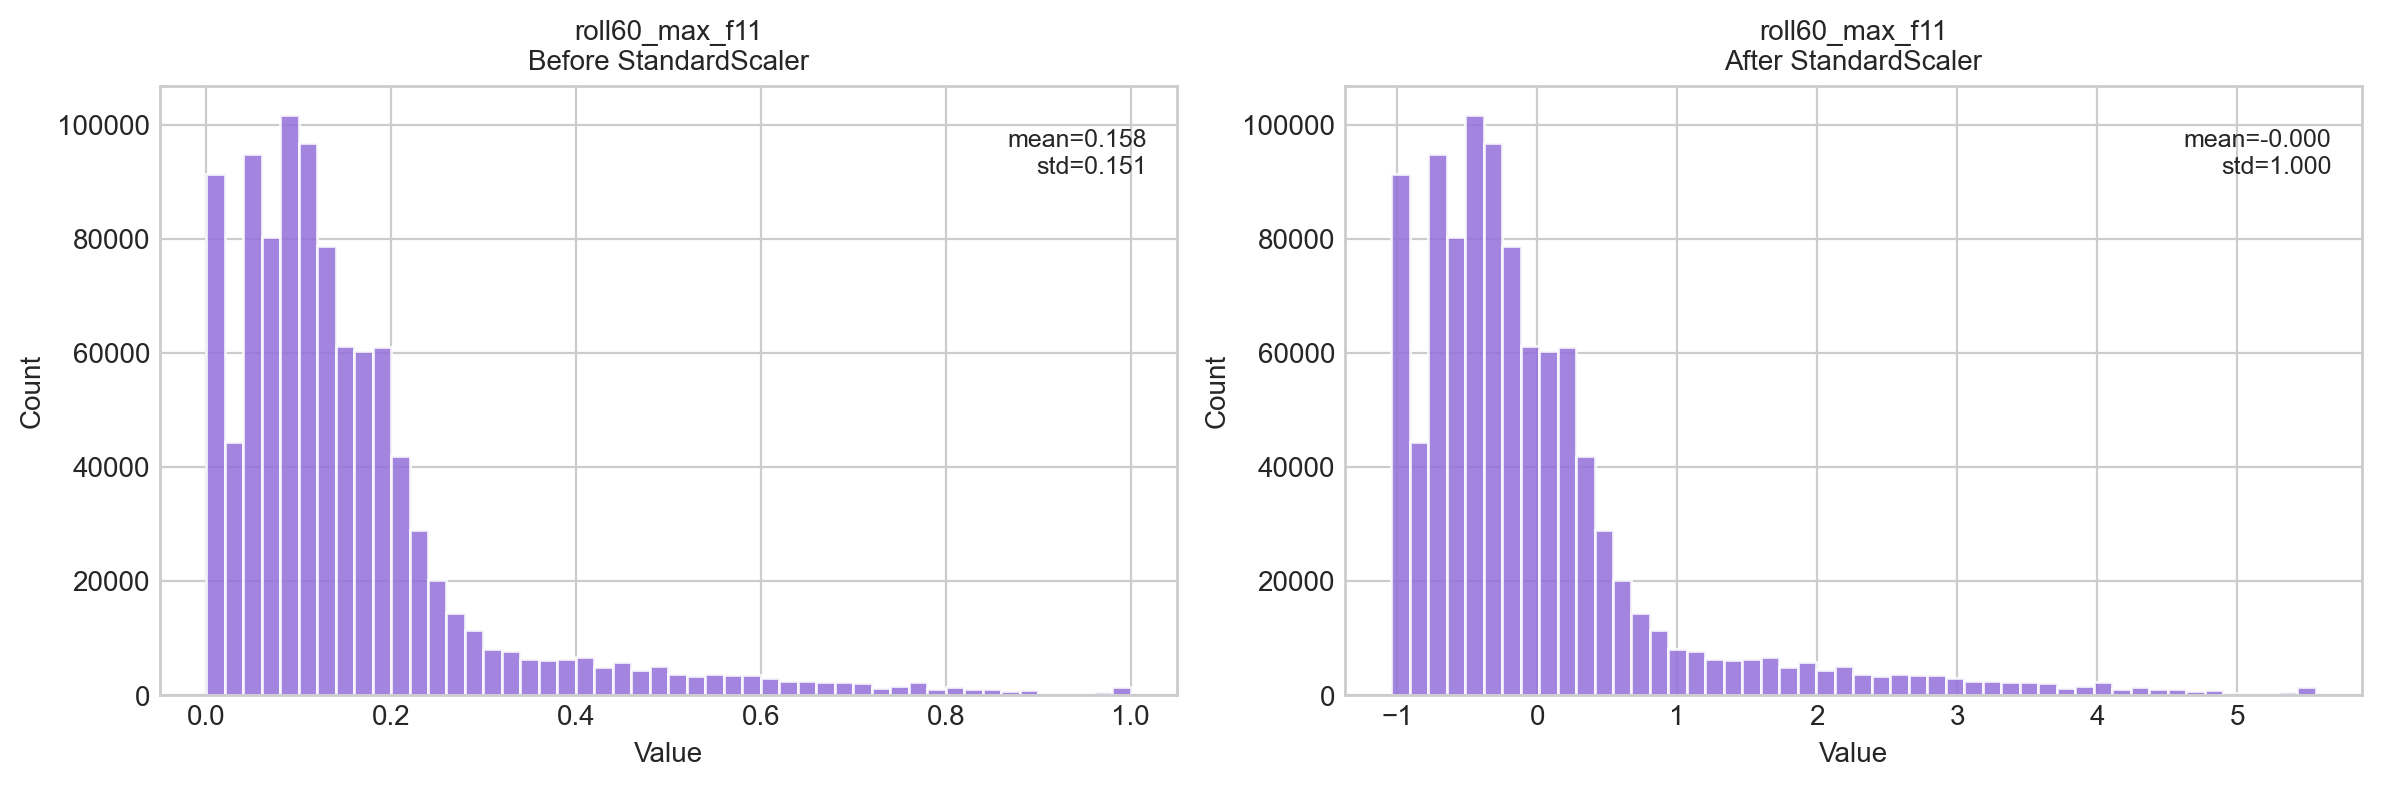

In [5]:
pipe = FeaturePipeline(sub_windows=SUB_WINDOWS)
X_tr_scaled = pipe.fit_transform(X_tr_raw)

feat_idx_example = top_feat_idx[0]
raw_vals    = X_tr_feats_raw[:, feat_idx_example]
scaled_vals = X_tr_scaled[:,   feat_idx_example]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, vals, title in [
    (axes[0], raw_vals,    'Before StandardScaler'),
    (axes[1], scaled_vals, 'After StandardScaler'),
]:
    ax.hist(vals, bins=50, color='mediumpurple', edgecolor='white', alpha=0.85)
    ax.set_title(f'{feat_names[feat_idx_example][:30]}\n{title}', fontsize=10)
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
    ax.text(0.97, 0.93, f'mean={vals.mean():.3f}\nstd={vals.std():.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9)

plt.tight_layout()
plt.show()

## 5. PCA: Are Incident Windows Separable?

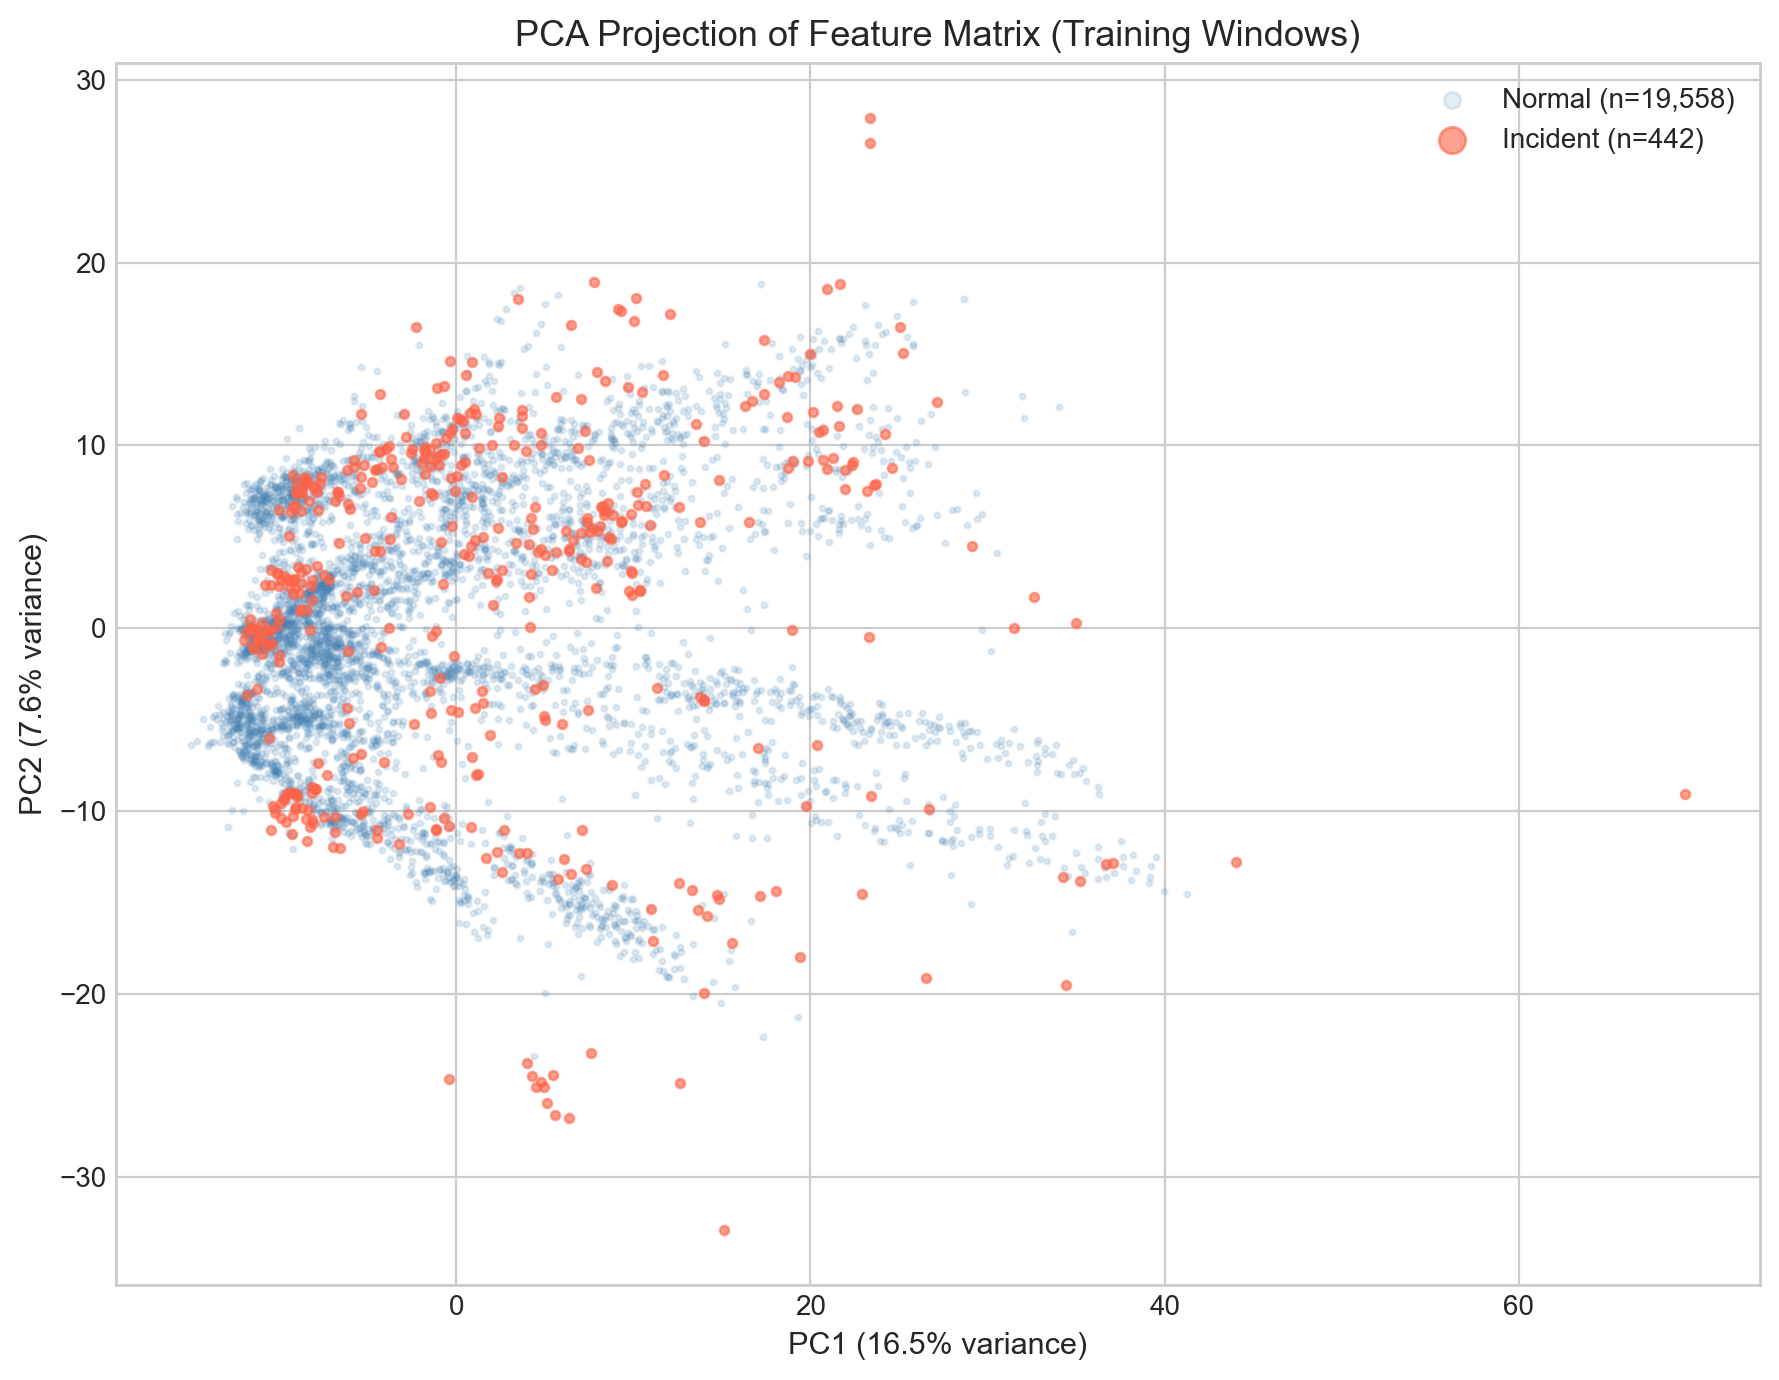

First 2 PCs explain 24.1% of total variance.
If incident windows form distinct clusters, the features have strong discriminative power.


In [7]:
from sklearn.decomposition import PCA

N_SAMPLE = min(20000, len(y_tr))
idx_sample = np.random.choice(len(y_tr), N_SAMPLE, replace=False)
X_sample = X_tr_scaled[idx_sample]
y_sample = y_tr[idx_sample]

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_sample)

neg_idx = np.where(y_sample == 0)[0]
pos_idx = np.where(y_sample == 1)[0]

neg_show = neg_idx[np.random.choice(len(neg_idx), min(5000, len(neg_idx)), replace=False)]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_2d[neg_show, 0], X_2d[neg_show, 1], s=4, alpha=0.15,
           color='steelblue', label=f'Normal (n={len(neg_idx):,})', rasterized=True)
ax.scatter(X_2d[pos_idx, 0], X_2d[pos_idx, 1],  s=10, alpha=0.6,
           color='tomato',    label=f'Incident (n={len(pos_idx):,})', rasterized=True)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('PCA Projection of Feature Matrix (Training Windows)', fontsize=13)
ax.legend(fontsize=10, markerscale=3)
plt.tight_layout()
plt.show()

total_var = pca.explained_variance_ratio_[:2].sum() * 100
print(f'First 2 PCs explain {total_var:.1f}% of total variance.')
print('If incident windows form distinct clusters, the features have strong discriminative power.')

## 6. Feature Engineering Summary

| Observation | Implication |
|-------------|-------------|
| No NaN or Inf values | Feature extraction is numerically stable |
| Features have very different raw scales | StandardScaler required for LR; trees are scale-invariant |
| Top features by Cohen's d are rolling stats and rate-of-change | These groups should have high importance in tree models |
| PCA shows partial separation | Non-linear decision boundaries needed for high recall |
